# 🟡 미션 2 — 잔차 연결이 정말 필요한가

수업에서 12층으로 봤다. 이번엔 **더 깊게** 쌓아서 차이가 얼마나 벌어지는지 직접 잰다.
그리고 **되돌아오는 기울기**까지 본다 — 학습이 되느냐 마느냐가 사실 여기 걸려 있다.

## 낼 것

1. 그래프 1장
2. 한 줄: **"몇 층쯤부터 잔차 없는 쪽이 못 쓰게 되나"**

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "missions" else Path.cwd()))

import matplotlib.pyplot as plt
import torch

import block
import koplot

koplot.use_korean()

[koplot] 한글 폰트 적용: Noto Sans KR


'Noto Sans KR'

## 1. 깊이를 바꿔 가며 신호가 남는지 본다

✍️ **깊이를 바꿔 본다.** 48, 96 도 해 보라 — 오래 걸리지 않는다.

In [2]:
깊이목록 = [2, 4, 8, 16, 24, 32]      # ✍️ 바꿔 본다
d = 16

torch.manual_seed(0)


def 통과(깊이, 잔차쓰기):
    """깊이만큼 쌓아 통과시킨 뒤, 남은 신호 크기와 되돌아온 기울기 크기를 돌려준다."""
    x0 = torch.randn(1, 6, d, requires_grad=True)
    층들 = [block.SelfAttention(d) for _ in range(깊이)]

    x = x0
    for 층 in 층들:
        서브, _ = 층(x)
        x = x + 서브 if 잔차쓰기 else 서브

    신호 = x.norm().item()
    x.sum().backward()                 # 맨 끝에서 거꾸로 되돌린다
    기울기 = x0.grad.norm().item()
    return 신호, 기울기

In [3]:
결과 = {"잔차 없이": [], "잔차 넣고": []}
기울기결과 = {"잔차 없이": [], "잔차 넣고": []}

for 깊이 in 깊이목록:
    for 이름, 쓰기 in [("잔차 없이", False), ("잔차 넣고", True)]:
        s, g = 통과(깊이, 쓰기)
        결과[이름].append(s)
        기울기결과[이름].append(g)

print(f"{'깊이':>6s} {'신호(없이)':>14s} {'신호(넣고)':>12s} {'기울기(없이)':>14s} {'기울기(넣고)':>14s}")
print("-" * 66)
for i, 깊이 in enumerate(깊이목록):
    print(f"{깊이:>6d} {결과['잔차 없이'][i]:>14.3e} {결과['잔차 넣고'][i]:>12.3f}"
          f" {기울기결과['잔차 없이'][i]:>14.3e} {기울기결과['잔차 넣고'][i]:>14.3f}")

    깊이         신호(없이)       신호(넣고)        기울기(없이)        기울기(넣고)
------------------------------------------------------------------
     2      2.282e-01        8.841      1.196e+00         12.173
     4      3.588e-02       11.456      6.281e-02         14.328
     8      2.271e-04       10.390      5.890e-04         13.011
    16      3.455e-08       12.207      2.064e-07         26.348
    24      1.783e-11        9.786      3.526e-12         29.903
    32      9.577e-17       13.612      3.306e-16         44.931


## 2. 그래프로

findfont: Failed to find font weight normal, now using 100.
findfont: Failed to find font weight normal, now using 100.
findfont: Failed to find font weight normal, now using 100.


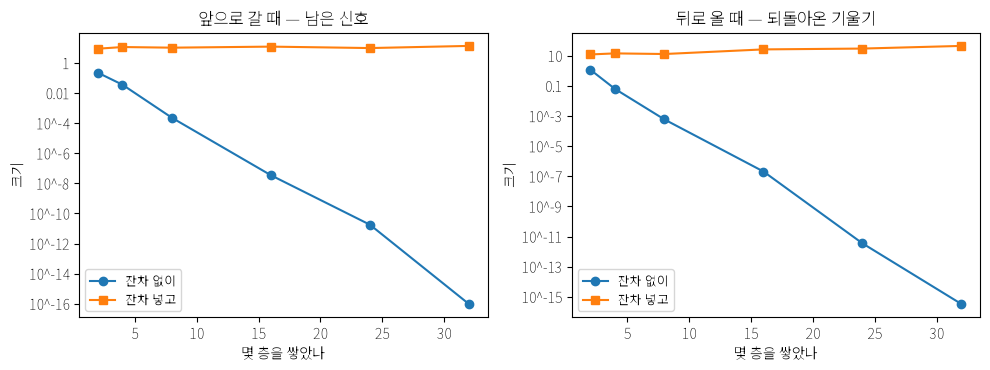

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

for ax, 자료, 제목 in [
    (axes[0], 결과, "앞으로 갈 때 — 남은 신호"),
    (axes[1], 기울기결과, "뒤로 올 때 — 되돌아온 기울기"),
]:
    for 이름, 표식 in [("잔차 없이", "o"), ("잔차 넣고", "s")]:
        ax.plot(깊이목록, 자료[이름], marker=표식, label=이름)
    ax.set_yscale("log")
    koplot.ascii_log_axis(ax, "y")
    ax.set_xlabel("몇 층을 쌓았나")
    ax.set_ylabel("크기")
    ax.set_title(제목)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 3. 왜 기울기가 더 중요한가

신호가 사라지는 것도 문제지만, **기울기가 0이면 학습 자체가 안 된다.**
앞쪽 층까지 "너 이렇게 고쳐" 라는 신호가 도달하지 못하기 때문이다.

잔차 연결이 있으면 `x + Sublayer(x)` 의 `x` 를 따라 기울기가 **곧장** 앞으로 흘러간다.
층을 아무리 많이 쌓아도 이 지름길은 그대로다. 그래서 **깊게 쌓을 수 있게 됐다.**

## ✍️ 제출 — 한 줄로 적는다

> 잔차 없이 쌓으면 약 ____ 층부터 신호(또는 기울기)가 사실상 0이 되어 학습이 불가능해진다.

> ⚠️ 여기 숫자는 **무작위 가중치**로 잰 것이라 돌릴 때마다 달라진다.
> 봐야 할 것은 **두 선이 갈라지는 모양**이지 특정 숫자가 아니다.